# 🚀 AdaBoost Time-Series Forecasting — `sales_amount_realistic`

This notebook implements an **AdaBoost Regressor** for time-series sales forecasting on Apple retail data.  
We apply best-practice preprocessing and feature engineering tailored to time-series:

| Stage | What we do |
|-------|------------|
| **Aggregation** | Roll transaction rows → monthly store-level summaries |
| **Lag features** | 1 – 6 month lags of target & quantity |
| **Rolling statistics** | 3/6/12-month rolling mean, std, min, max of target |
| **Cyclical encoding** | Sine / cosine of month |
| **Economic rates of change** | GDP growth, inflation Δ, exchange-rate Δ, internet Δ |
| **Category / store encoding** | Target-encoded category, label-encoded store |
| **Trend & momentum** | Month-over-month % change, expanding mean |
| **Hyperparameter tuning** | `TimeSeriesSplit` cross-validation with grid search |
| **Evaluation** | MAE, RMSE, MAPE, R² on a strict temporal hold-out |
| **Future forecast** | One-month-ahead prediction (Jan 2025) |

## 1 · Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})

sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All imports loaded successfully.')

✅ All imports loaded successfully.


## 2 · Data Loading

In [2]:
PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / 'data' / 'processed'

df_raw = pd.read_csv(PROC / 'cleaned_apple_sales_enriched_realistic.csv')
print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Raw dataset: 1,040,200 rows × 36 columns


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month,launch_year
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,199,Apple Central World,Bangkok,...,199.0,0,0.000783,1.0,1.219421,1.039677,3,597.0,1,2020
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,429,Apple Shinjuku,Tokyo,...,429.0,0,0.000154,1.0,1.172288,10.813781,6,2574.0,1,2020
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,199,Apple Park Visitor Center,Cupertino,...,199.0,0,0.000783,1.0,0.958735,6.406862,5,995.0,1,2020


In [3]:
# Quick sanity checks
print('Null counts (top 10):')
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))
print(f"\nDate range: {df_raw['sale_date'].min()} → {df_raw['sale_date'].max()}")
print(f'Unique stores: {df_raw["store_id"].nunique()}  |  Unique products: {df_raw["product_id"].nunique()}')

Null counts (top 10):
sale_id         0
sale_date       0
store_id        0
product_id      0
quantity        0
product_name    0
launch_date     0
price           0
store_name      0
city            0
dtype: int64

Date range: 2020-01-01 → 2024-11-12
Unique stores: 75  |  Unique products: 89


## 3 · Preprocessing — Monthly Store-Level Aggregation

AdaBoost (like all tree-based boosters) works on **tabular rows**, not raw sequences.  
We aggregate transaction-level data into **monthly summaries per store** — this is the natural granularity for retail forecasting and matches the existing project convention.

In [4]:
# Parse dates
df_raw['sale_date'] = pd.to_datetime(df_raw['sale_date'])
df_raw['year'] = df_raw['sale_date'].dt.year
df_raw['month'] = df_raw['sale_date'].dt.month

# Monthly aggregation per store
df_monthly = df_raw.groupby([
    'store_id', 'store_name', 'country_norm_mapped', 'year', 'month'
]).agg(
    sales_amount_realistic=('sales_amount_realistic', 'sum'),
    quantity_realistic=('quantity_realistic', 'sum'),
    price_realistic=('price_realistic', 'mean'),
    num_transactions=('sale_id', 'count'),
    num_unique_products=('product_id', 'nunique'),
    promo_flag=('promo_flag', 'mean'),          # fraction of promo transactions
    gdp_per_capita=('gdp_per_capita', 'mean'),
    inflation_rate=('inflation_rate', 'mean'),
    exchange_rate=('exchange_rate', 'mean'),
    internet_usage_pct=('internet_usage_pct', 'mean'),
    num_categories=('category_name', 'nunique'),
).reset_index()

# Build a proper datetime column
df_monthly['date'] = pd.to_datetime(
    df_monthly[['year', 'month']].assign(day=1)
)

# Sort chronologically within each store
df_monthly = df_monthly.sort_values(['store_id', 'date']).reset_index(drop=True)

print(f'Monthly dataset: {df_monthly.shape[0]:,} rows × {df_monthly.shape[1]} columns')
print(f'Date range: {df_monthly["date"].min().date()} → {df_monthly["date"].max().date()}')
df_monthly.head()

Monthly dataset: 4,425 rows × 17 columns
Date range: 2020-01-01 → 2024-11-01


,store_id,store_name,country_norm_mapped,year,month,sales_amount_realistic,quantity_realistic,price_realistic,num_transactions,num_unique_products,promo_flag,gdp_per_capita,inflation_rate,exchange_rate,internet_usage_pct,num_categories,date
0,ST-1,Apple Fifth Avenue,united states,2020,1,1165095.0,1513,886.059259,270,83,0.100000,64401.50744,1.233584,1.0,90.3447,10,2020-01-01
1,ST-1,Apple Fifth Avenue,united states,2020,2,1514568.0,1650,850.099174,242,84,0.099174,64401.50744,1.233584,1.0,90.3447,10,2020-02-01
2,ST-1,Apple Fifth Avenue,united states,2020,3,1293684.0,1674,760.186047,258,83,0.058140,64401.50744,1.233584,1.0,90.3447,10,2020-03-01
3,ST-1,Apple Fifth Avenue,united states,2020,4,1213496.0,1702,695.834043,235,82,0.114894,64401.50744,1.233584,1.0,90.3447,10,2020-04-01
4,ST-1,Apple Fifth Avenue,united states,2020,5,1247788.0,1802,785.638655,238,79,0.096639,64401.50744,1.233584,1.0,90.3447,10,2020-05-01


## 4 · Feature Engineering

We create features that capture temporal patterns, economic context, and store behaviour.

### 4.1 · Cyclical Time Encoding

In [5]:
# Cyclical encoding preserves the circular nature of months (Dec→Jan continuity)
df_monthly['month_sin'] = np.sin(2 * np.pi * df_monthly['month'] / 12)
df_monthly['month_cos'] = np.cos(2 * np.pi * df_monthly['month'] / 12)

# Quarter
df_monthly['quarter'] = df_monthly['month'].apply(lambda m: (m - 1) // 3 + 1)
df_monthly['quarter_sin'] = np.sin(2 * np.pi * df_monthly['quarter'] / 4)
df_monthly['quarter_cos'] = np.cos(2 * np.pi * df_monthly['quarter'] / 4)

# Is holiday season (Nov-Dec)
df_monthly['is_holiday_season'] = df_monthly['month'].isin([11, 12]).astype(int)

# Is new-product season (Sep-Oct, when Apple typically launches)
df_monthly['is_launch_season'] = df_monthly['month'].isin([9, 10]).astype(int)

print('✅ Cyclical & seasonal features added.')

✅ Cyclical & seasonal features added.


### 4.2 · Economic Indicators — Rates of Change

In [6]:
# Compute month-over-month percentage change per country for macro indicators
for col in ['gdp_per_capita', 'inflation_rate', 'exchange_rate', 'internet_usage_pct']:
    change_col = col.replace('_per_capita', '').replace('_rate', '').replace('_pct', '') + '_change'
    df_monthly[change_col] = (
        df_monthly
        .groupby('country_norm_mapped')[col]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

print('✅ Economic change features added.')
print('New columns:', [c for c in df_monthly.columns if '_change' in c])

✅ Economic change features added.
New columns: ['gdp_change', 'inflation_change', 'exchange_change', 'internet_usage_change']


### 4.3 · Lag Features (Target & Quantity)

In [7]:
# Lag features — critical for time-series; we use groupby to prevent leakage across stores
LAG_MONTHS = [1, 2, 3, 4, 5, 6]

for lag in LAG_MONTHS:
    df_monthly[f'sales_lag_{lag}'] = (
        df_monthly.groupby('store_id')['sales_amount_realistic'].shift(lag)
    )
    df_monthly[f'qty_lag_{lag}'] = (
        df_monthly.groupby('store_id')['quantity_realistic'].shift(lag)
    )

# Year-over-year lag (same month last year)
df_monthly['sales_lag_12'] = df_monthly.groupby('store_id')['sales_amount_realistic'].shift(12)
df_monthly['qty_lag_12'] = df_monthly.groupby('store_id')['quantity_realistic'].shift(12)

print(f'✅ Lag features added: {len(LAG_MONTHS)} monthly + 1 yearly, for both sales and quantity.')

✅ Lag features added: 6 monthly + 1 yearly, for both sales and quantity.


### 4.4 · Rolling Window Statistics

In [8]:
# Rolling statistics on the target (computed per store to avoid leakage)
WINDOWS = [3, 6, 12]

for w in WINDOWS:
    grp = df_monthly.groupby('store_id')['sales_amount_realistic']
    # shift(1) ensures we never use the current month's actual sales
    df_monthly[f'sales_roll_mean_{w}'] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    df_monthly[f'sales_roll_std_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
    df_monthly[f'sales_roll_min_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).min())
    df_monthly[f'sales_roll_max_{w}']  = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).max())

# Rolling mean of quantity
for w in [3, 6]:
    df_monthly[f'qty_roll_mean_{w}'] = (
        df_monthly.groupby('store_id')['quantity_realistic']
        .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )

print(f'✅ Rolling window features added for windows: {WINDOWS}')

✅ Rolling window features added for windows: [3, 6, 12]


### 4.5 · Trend & Momentum Features

In [9]:
# Month-over-month percentage change (momentum)
df_monthly['sales_mom_pct'] = (
    df_monthly.groupby('store_id')['sales_amount_realistic']
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Expanding (cumulative) mean — captures long-term level per store
df_monthly['sales_expanding_mean'] = (
    df_monthly.groupby('store_id')['sales_amount_realistic']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

# Ratio of current lag to rolling mean (deviation signal)
df_monthly['sales_lag1_vs_roll6'] = (
    df_monthly['sales_lag_1'] / df_monthly['sales_roll_mean_6'].replace(0, np.nan)
).fillna(1)

print('✅ Trend & momentum features added.')

✅ Trend & momentum features added.


### 4.6 · Store & Category Encoding

In [10]:
# Label-encode store_id and country
le_store = LabelEncoder()
df_monthly['store_encoded'] = le_store.fit_transform(df_monthly['store_id'])

le_country = LabelEncoder()
df_monthly['country_encoded'] = le_country.fit_transform(df_monthly['country_norm_mapped'])

# Target-encode store by its historical mean sales (avoids high-cardinality issues)
store_target_mean = df_monthly.groupby('store_id')['sales_amount_realistic'].transform('mean')
df_monthly['store_target_enc'] = store_target_mean

print('✅ Categorical encoding complete.')
print(f'   store_encoded  range: [{df_monthly["store_encoded"].min()}, {df_monthly["store_encoded"].max()}]')
print(f'   country_encoded range: [{df_monthly["country_encoded"].min()}, {df_monthly["country_encoded"].max()}]')

✅ Categorical encoding complete.
   store_encoded  range: [0, 74]
   country_encoded range: [0, 18]


### 4.7 · Handle Missing Values from Lag/Rolling

In [11]:
# Count NaNs introduced by lag/rolling before filling
nan_before = df_monthly.isnull().sum()
print('Columns with NaN (from lag/rolling):')
print(nan_before[nan_before > 0])

# Drop the first 6 months of each store (they have mostly NaN lags)
df_monthly['row_num'] = df_monthly.groupby('store_id').cumcount()
df_clean = df_monthly[df_monthly['row_num'] >= 6].copy()
df_clean.drop(columns='row_num', inplace=True)
df_monthly.drop(columns='row_num', inplace=True)

# Fill any remaining NaNs with 0 (edge cases in rolling std)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

print(f'\nAfter cleanup: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Remaining NaNs: {df_clean.isnull().sum().sum()}')

Columns with NaN (from lag/rolling):
sales_lag_1              75
qty_lag_1                75
sales_lag_2             150
qty_lag_2               150
sales_lag_3             225
qty_lag_3               225
sales_lag_4             300
qty_lag_4               300
sales_lag_5             375
qty_lag_5               375
sales_lag_6             450
qty_lag_6               450
sales_lag_12            900
qty_lag_12              900
sales_roll_mean_3        75
sales_roll_std_3        150
sales_roll_min_3         75
sales_roll_max_3         75
sales_roll_mean_6        75
sales_roll_std_6        150
sales_roll_min_6         75
sales_roll_max_6         75
sales_roll_mean_12       75
sales_roll_std_12       150
sales_roll_min_12        75
sales_roll_max_12        75
qty_roll_mean_3          75
qty_roll_mean_6          75
sales_expanding_mean     75
dtype: int64

After cleanup: 3,975 rows × 62 columns
Remaining NaNs: 0


## 5 · Feature Selection & Train/Test Split

In [12]:
# Define the full feature set
TARGET = 'sales_amount_realistic'

FEATURES = [
    # ─── Lagged target & quantity ───
    'sales_lag_1', 'sales_lag_2', 'sales_lag_3',
    'sales_lag_4', 'sales_lag_5', 'sales_lag_6', 'sales_lag_12',
    'qty_lag_1', 'qty_lag_2', 'qty_lag_3',
    'qty_lag_4', 'qty_lag_5', 'qty_lag_6', 'qty_lag_12',

    # ─── Rolling statistics ───
    'sales_roll_mean_3', 'sales_roll_std_3', 'sales_roll_min_3', 'sales_roll_max_3',
    'sales_roll_mean_6', 'sales_roll_std_6', 'sales_roll_min_6', 'sales_roll_max_6',
    'sales_roll_mean_12', 'sales_roll_std_12', 'sales_roll_min_12', 'sales_roll_max_12',
    'qty_roll_mean_3', 'qty_roll_mean_6',

    # ─── Trend & momentum ───
    'sales_mom_pct', 'sales_expanding_mean', 'sales_lag1_vs_roll6',

    # ─── Price & promo ───
    'price_realistic', 'promo_flag',

    # ─── Time / seasonal ───
    'month_sin', 'month_cos',
    'quarter_sin', 'quarter_cos',
    'year',
    'is_holiday_season', 'is_launch_season',

    # ─── Economic context ───
    'gdp_per_capita', 'inflation_rate', 'exchange_rate', 'internet_usage_pct',
    'gdp_change', 'inflation_change', 'exchange_change', 'internet_usage_change',

    # ─── Store / categorical ───
    'store_encoded', 'country_encoded', 'store_target_enc',
    'num_transactions', 'num_unique_products', 'num_categories',
]

# Verify all features exist
missing_feats = [f for f in FEATURES if f not in df_clean.columns]
if missing_feats:
    print(f'⚠️  Missing features: {missing_feats}')
else:
    print(f'✅ All {len(FEATURES)} features available.')

✅ All 54 features available.


In [13]:
# ── Temporal train/test split ──
# Use the last 6 months as the test set (time-series best practice)
CUTOFF_DATE = df_clean['date'].max() - pd.DateOffset(months=5)
print(f'Train: everything before {CUTOFF_DATE.date()}')
print(f'Test:  {CUTOFF_DATE.date()} → {df_clean["date"].max().date()}')

train_mask = df_clean['date'] < CUTOFF_DATE
test_mask  = df_clean['date'] >= CUTOFF_DATE

X_train = df_clean.loc[train_mask, FEATURES]
y_train = df_clean.loc[train_mask, TARGET]
X_test  = df_clean.loc[test_mask, FEATURES]
y_test  = df_clean.loc[test_mask, TARGET]

print(f'\nTrain: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

Train: everything before 2024-06-01
Test:  2024-06-01 → 2024-11-01

Train: 3,525 samples
Test:  450 samples


## 6 · Baseline AdaBoost Model

In [14]:
%%time

# Baseline model with default hyperparameters
ada_baseline = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6),
    n_estimators=200,
    learning_rate=0.1,
    loss='linear',
    random_state=RANDOM_STATE
)

ada_baseline.fit(X_train, y_train)
y_pred_base = ada_baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mape_base = mean_absolute_percentage_error(y_test, y_pred_base) * 100
r2_base   = r2_score(y_test, y_pred_base)

print('\n─── Baseline AdaBoost Results ───')
print(f'  MAE  = {mae_base:,.2f}')
print(f'  RMSE = {rmse_base:,.2f}')
print(f'  MAPE = {mape_base:.2f}%')
print(f'  R²   = {r2_base:.4f}')


─── Baseline AdaBoost Results ───
  MAE  = 78,227.54
  RMSE = 124,425.03
  MAPE = 12.67%
  R²   = 0.9248
CPU times: total: 8.2 s
Wall time: 8.2 s


## 7 · Hyperparameter Tuning with TimeSeriesSplit

We use `TimeSeriesSplit` instead of random K-Fold to **respect temporal ordering** and prevent data leakage.

In [15]:
%%time

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'estimator__max_depth': [4, 6, 8, 10],
}

ada_search = GridSearchCV(
    estimator=AdaBoostRegressor(
        estimator=DecisionTreeRegressor(),
        loss='linear',
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

ada_search.fit(X_train, y_train)

print(f'\n✅ Best parameters: {ada_search.best_params_}')
print(f'   Best CV MAE: {-ada_search.best_score_:,.2f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ Best parameters: {'estimator__max_depth': 8, 'learning_rate': 0.5, 'n_estimators': 300}
   Best CV MAE: 62,092.49
CPU times: total: 16.7 s
Wall time: 2min 58s


## 8 · Tuned Model — Evaluation

In [16]:
# Use the best estimator from grid search
ada_best = ada_search.best_estimator_
y_pred_tuned = ada_best.predict(X_test)

mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mape_tuned = mean_absolute_percentage_error(y_test, y_pred_tuned) * 100
r2_tuned   = r2_score(y_test, y_pred_tuned)

print('─── Tuned AdaBoost Results ───')
print(f'  MAE  = {mae_tuned:,.2f}')
print(f'  RMSE = {rmse_tuned:,.2f}')
print(f'  MAPE = {mape_tuned:.2f}%')
print(f'  R²   = {r2_tuned:.4f}')

print('\n─── Improvement over Baseline ───')
print(f'  MAE  improvement: {(mae_base - mae_tuned) / mae_base * 100:+.2f}%')
print(f'  R²   improvement: {(r2_tuned - r2_base):+.4f}')

─── Tuned AdaBoost Results ───
  MAE  = 51,999.83
  RMSE = 91,244.77
  MAPE = 9.35%
  R²   = 0.9595

─── Improvement over Baseline ───
  MAE  improvement: +33.53%
  R²   improvement: +0.0348


In [17]:
# Summary comparison table
results_df = pd.DataFrame({
    'Model': ['AdaBoost (Baseline)', 'AdaBoost (Tuned)'],
    'MAE': [mae_base, mae_tuned],
    'RMSE': [rmse_base, rmse_tuned],
    'MAPE (%)': [mape_base, mape_tuned],
    'R²': [r2_base, r2_tuned]
})
results_df.style.format({'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE (%)': '{:.2f}', 'R²': '{:.4f}'})

,Model,MAE,RMSE,MAPE (%),R²
0,AdaBoost (Baseline),"78,227.54","124,425.03",12.67,0.9248
1,AdaBoost (Tuned),"51,999.83","91,244.77",9.35,0.9595


## 9 · Visualizations

### 9.1 · Feature Importance (Top 20)

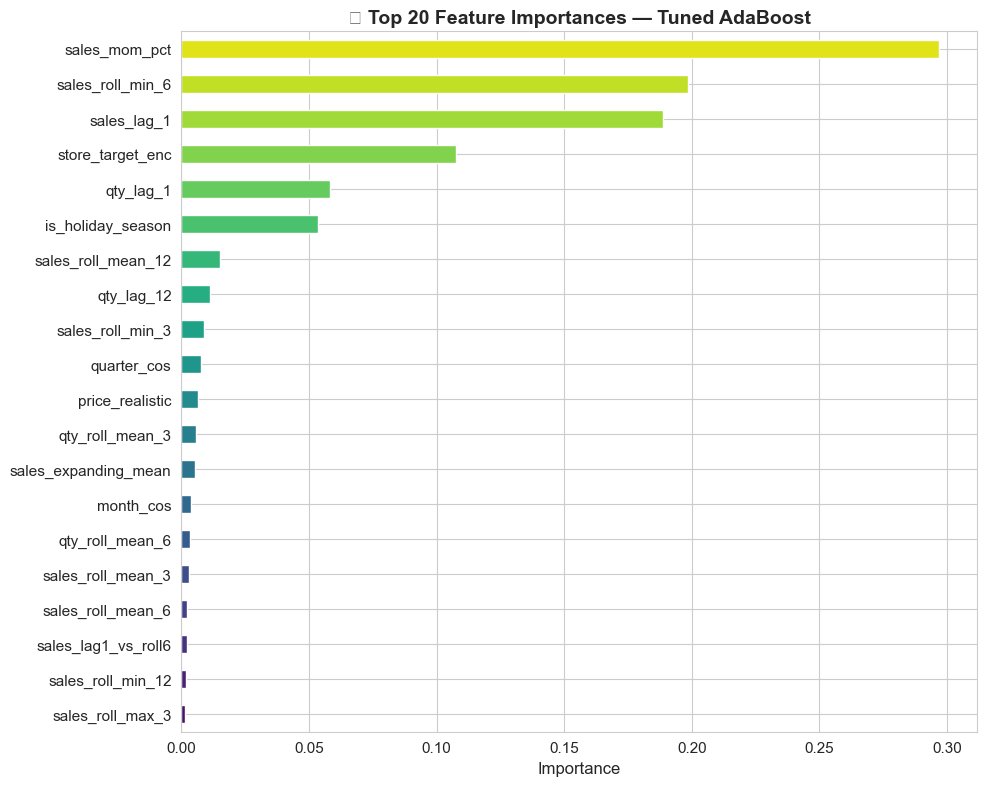

In [18]:
importances = pd.Series(ada_best.feature_importances_, index=FEATURES)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot.barh(ax=ax, color=sns.color_palette('viridis', 20))
ax.set_title('🔑 Top 20 Feature Importances — Tuned AdaBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 9.2 · Actual vs Predicted — Scatter Plot

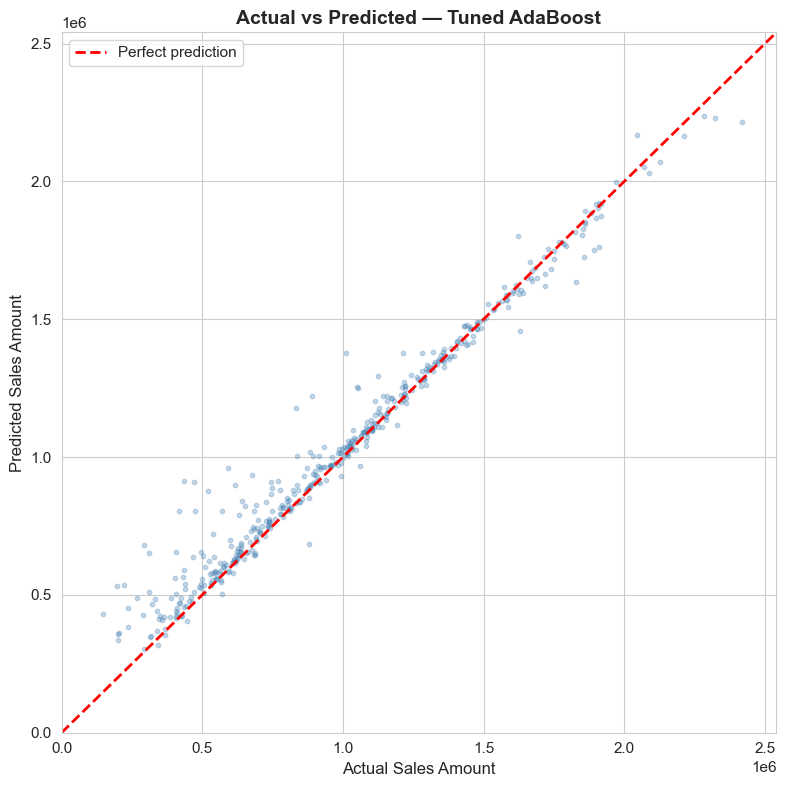

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_tuned, alpha=0.3, s=10, c='steelblue')
lims = [0, max(y_test.max(), y_pred_tuned.max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual Sales Amount')
ax.set_ylabel('Predicted Sales Amount')
ax.set_title('Actual vs Predicted — Tuned AdaBoost', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 9.3 · Residual Distribution

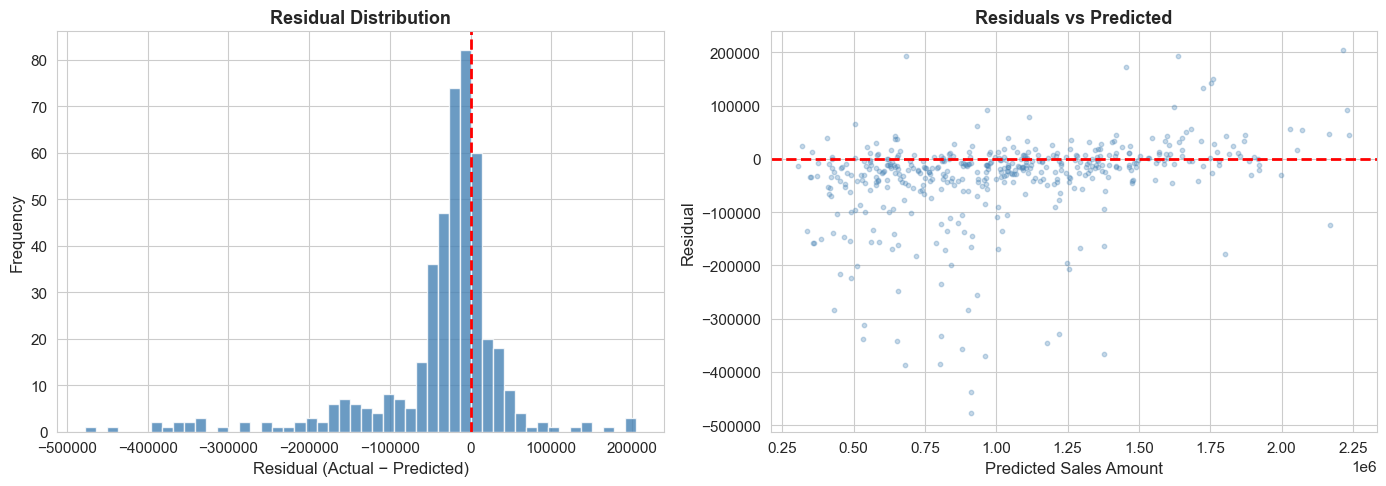

In [20]:
residuals = y_test.values - y_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Frequency')

# Residuals vs Predicted
axes[1].scatter(y_pred_tuned, residuals, alpha=0.3, s=10, c='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Sales Amount')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

### 9.4 · Actual vs Predicted — Time Series for Sample Stores

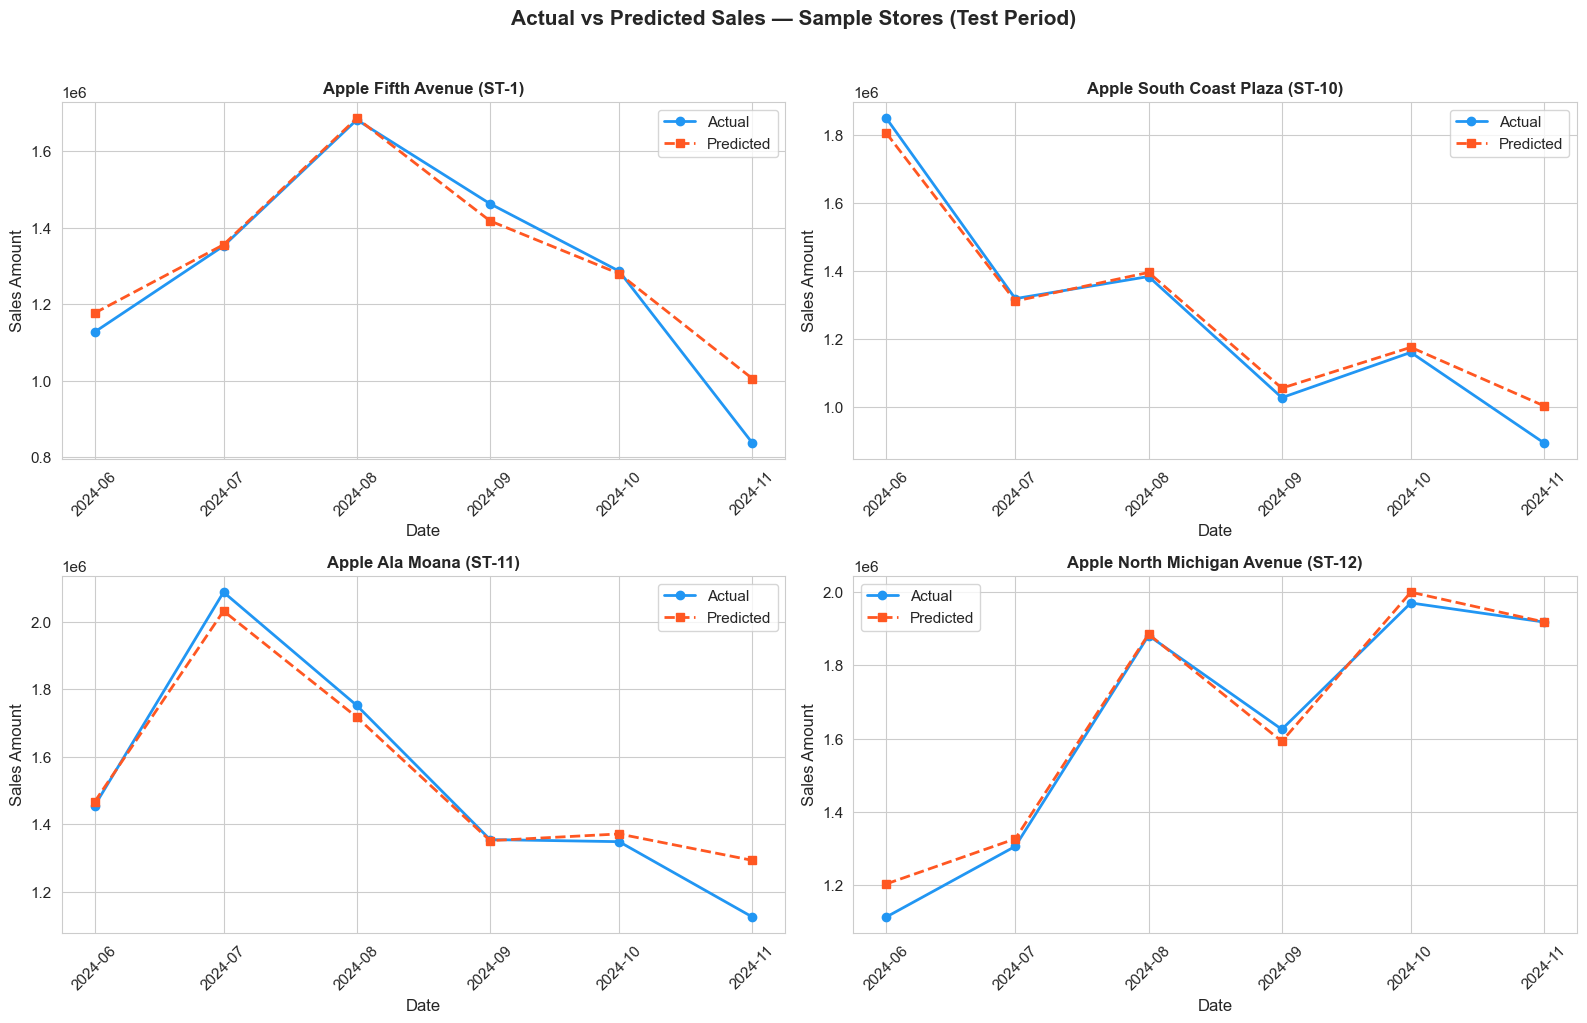

In [21]:
# Pick 4 stores with the most test data for a clear visual
test_data = df_clean.loc[test_mask].copy()
test_data['y_pred'] = y_pred_tuned

top_stores = test_data.groupby('store_id').size().nlargest(4).index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, store in zip(axes.flat, top_stores):
    store_df = test_data[test_data['store_id'] == store].sort_values('date')
    store_name = store_df['store_name'].iloc[0]

    ax.plot(store_df['date'], store_df[TARGET], 'o-', label='Actual', color='#2196F3', linewidth=2)
    ax.plot(store_df['date'], store_df['y_pred'], 's--', label='Predicted', color='#FF5722', linewidth=2)
    ax.set_title(f'{store_name} ({store})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales Amount')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Actual vs Predicted Sales — Sample Stores (Test Period)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.5 · Overall Aggregated Actual vs Predicted over Time

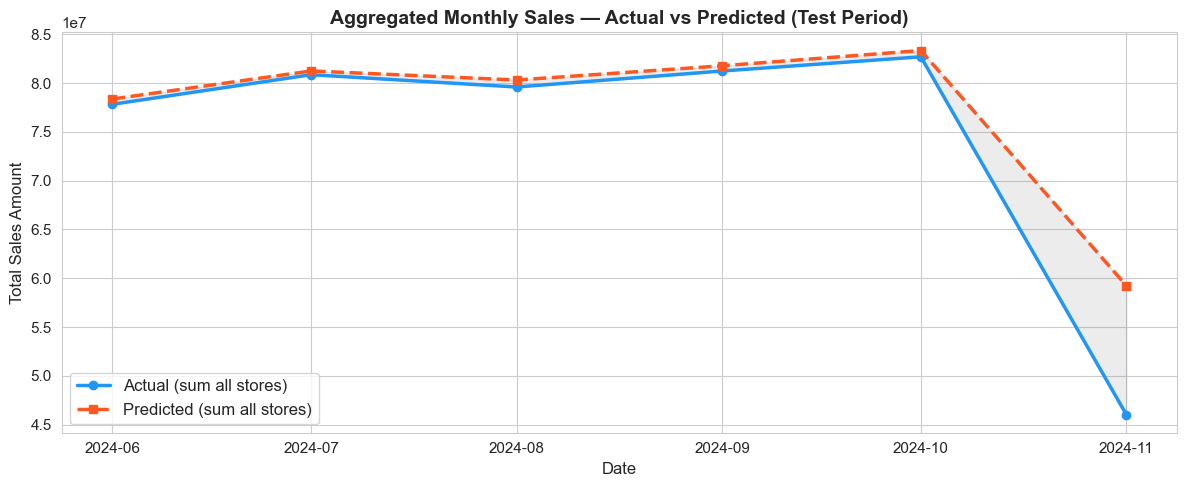

In [22]:
# Aggregate across all stores by month
agg = test_data.groupby('date').agg(
    actual=(TARGET, 'sum'),
    predicted=('y_pred', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agg['date'], agg['actual'], 'o-', label='Actual (sum all stores)', color='#2196F3', linewidth=2.5)
ax.plot(agg['date'], agg['predicted'], 's--', label='Predicted (sum all stores)', color='#FF5722', linewidth=2.5)
ax.fill_between(agg['date'], agg['actual'], agg['predicted'], alpha=0.15, color='gray')
ax.set_title('Aggregated Monthly Sales — Actual vs Predicted (Test Period)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales Amount')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 9.6 · Per-Store Error Distribution

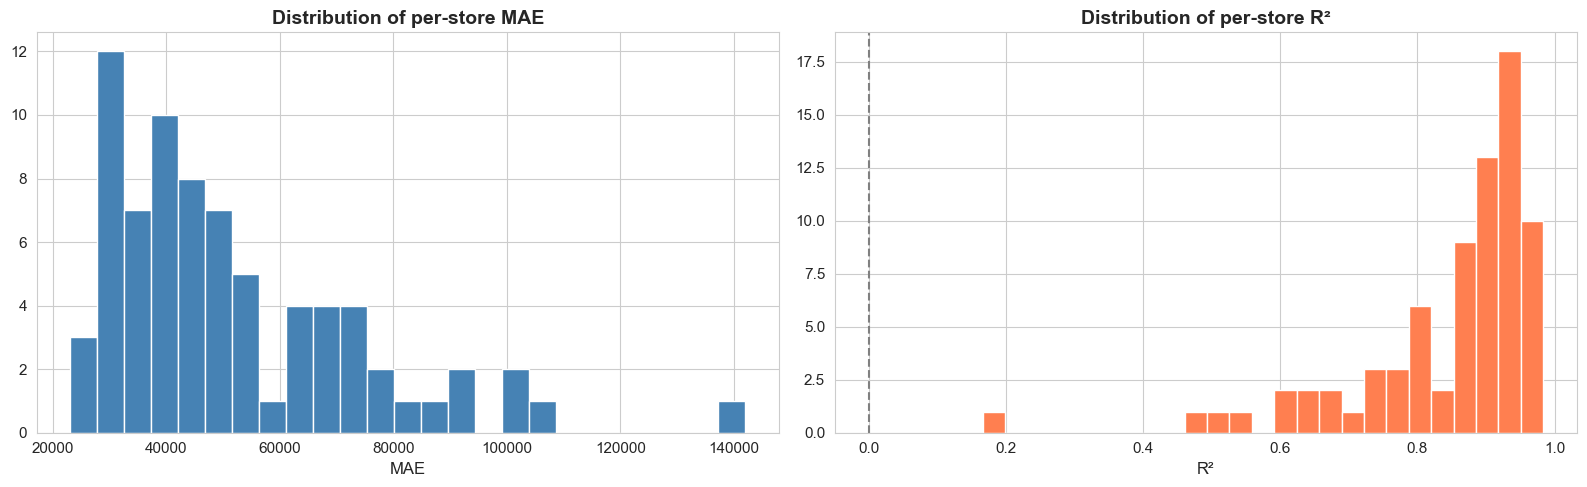

Median store-level MAE: 46,200.80
Median store-level R²: 0.8947


In [23]:
store_metrics = test_data.groupby('store_id').apply(
    lambda g: pd.Series({
        'MAE': mean_absolute_error(g[TARGET], g['y_pred']),
        'R2': r2_score(g[TARGET], g['y_pred']) if len(g) > 1 else np.nan,
        'store_name': g['store_name'].iloc[0]
    })
).reset_index()

store_metrics['MAE'] = store_metrics['MAE'].astype(float)
store_metrics['R2'] = store_metrics['R2'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(store_metrics['MAE'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of per-store MAE', fontweight='bold')
axes[0].set_xlabel('MAE')

axes[1].hist(store_metrics['R2'].dropna(), bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_title('Distribution of per-store R²', fontweight='bold')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.show()

print(f'Median store-level MAE: {store_metrics["MAE"].median():,.2f}')
print(f'Median store-level R²: {store_metrics["R2"].median():.4f}')

## 10 · Learning Curve — Number of Estimators

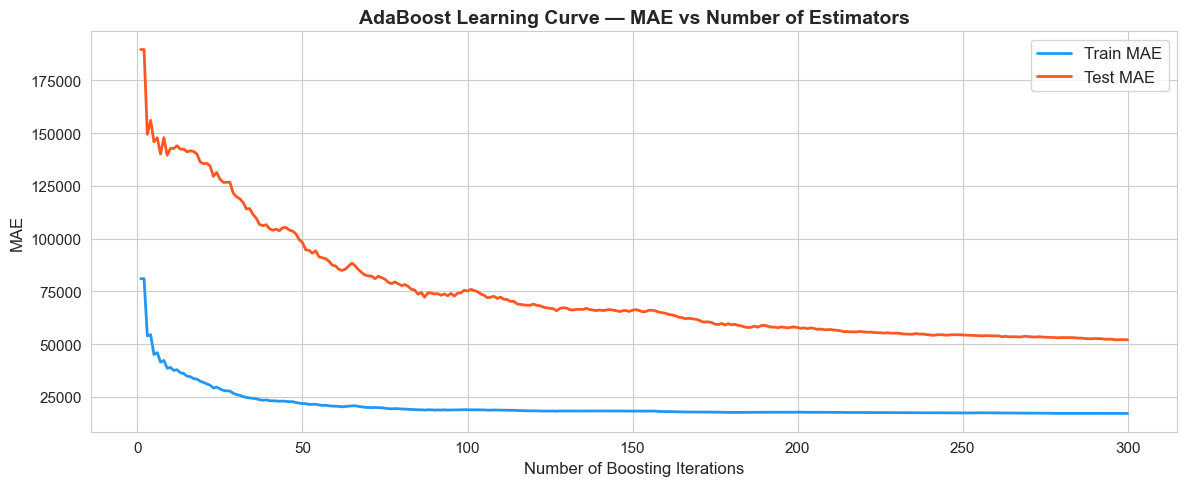

Optimal number of estimators (lowest test MAE): 297


In [24]:
# Show how error evolves as we add more weak learners
staged_errors_train = []
staged_errors_test = []

for y_staged in ada_best.staged_predict(X_train):
    staged_errors_train.append(mean_absolute_error(y_train, y_staged))
for y_staged in ada_best.staged_predict(X_test):
    staged_errors_test.append(mean_absolute_error(y_test, y_staged))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(staged_errors_train) + 1), staged_errors_train, label='Train MAE', color='#2196F3', linewidth=2)
ax.plot(range(1, len(staged_errors_test) + 1), staged_errors_test, label='Test MAE', color='#FF5722', linewidth=2)
ax.set_xlabel('Number of Boosting Iterations')
ax.set_ylabel('MAE')
ax.set_title('AdaBoost Learning Curve — MAE vs Number of Estimators', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

best_n = np.argmin(staged_errors_test) + 1
print(f'Optimal number of estimators (lowest test MAE): {best_n}')

## 11 · Future Forecast — Jan 2025

We predict **one month ahead** (January 2025) for every store, using the last known history to build lag and rolling features.

In [25]:
# Retrain on ALL available data for the best possible future forecast
X_all = df_clean[FEATURES]
y_all = df_clean[TARGET]

ada_final = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=ada_search.best_params_.get('estimator__max_depth', 6)),
    n_estimators=ada_search.best_params_.get('n_estimators', 200),
    learning_rate=ada_search.best_params_.get('learning_rate', 0.1),
    loss='linear',
    random_state=RANDOM_STATE
)

ada_final.fit(X_all, y_all)
print('✅ Final model retrained on all data.')

✅ Final model retrained on all data.


In [26]:
# One-month-ahead forecast: predict January 2025 for every store
FORECAST_DATE = pd.Timestamp('2025-01-01')
FORECAST_MONTH = FORECAST_DATE.month   # 1
FORECAST_YEAR  = FORECAST_DATE.year    # 2025

stores = df_clean['store_id'].unique()
all_forecasts = []

for store in stores:
    # Use the last 12 months of history for this store
    store_hist = df_clean[df_clean['store_id'] == store].sort_values('date').tail(12).copy()
    store_name = store_hist['store_name'].iloc[0]
    country = store_hist['country_norm_mapped'].iloc[0]

    recent_sales = store_hist['sales_amount_realistic'].tolist()
    recent_qty   = store_hist['quantity_realistic'].tolist()

    m, y = FORECAST_MONTH, FORECAST_YEAR
    row = {}

    # Lags from recent_sales
    for lag in LAG_MONTHS:
        row[f'sales_lag_{lag}'] = recent_sales[-lag] if lag <= len(recent_sales) else 0
        row[f'qty_lag_{lag}']   = recent_qty[-lag]   if lag <= len(recent_qty)   else 0
    row['sales_lag_12'] = recent_sales[-12] if len(recent_sales) >= 12 else 0
    row['qty_lag_12']   = recent_qty[-12]   if len(recent_qty)   >= 12 else 0

    # Rolling stats
    for w in WINDOWS:
        window = recent_sales[-w:] if len(recent_sales) >= w else recent_sales
        row[f'sales_roll_mean_{w}'] = np.mean(window)
        row[f'sales_roll_std_{w}']  = np.std(window) if len(window) > 1 else 0
        row[f'sales_roll_min_{w}']  = np.min(window)
        row[f'sales_roll_max_{w}']  = np.max(window)
    for w in [3, 6]:
        window = recent_qty[-w:] if len(recent_qty) >= w else recent_qty
        row[f'qty_roll_mean_{w}'] = np.mean(window)

    # Trend & momentum
    row['sales_mom_pct'] = (recent_sales[-1] - recent_sales[-2]) / max(recent_sales[-2], 1) if len(recent_sales) >= 2 else 0
    row['sales_expanding_mean'] = np.mean(recent_sales)
    roll6_mean = np.mean(recent_sales[-6:]) if len(recent_sales) >= 6 else np.mean(recent_sales)
    row['sales_lag1_vs_roll6'] = recent_sales[-1] / max(roll6_mean, 1)

    # Price & promo
    row['price_realistic'] = store_hist['price_realistic'].iloc[-1]
    row['promo_flag']      = store_hist['promo_flag'].iloc[-1]

    # Time / seasonal
    row['month_sin'] = np.sin(2 * np.pi * m / 12)
    row['month_cos'] = np.cos(2 * np.pi * m / 12)
    q = (m - 1) // 3 + 1
    row['quarter_sin'] = np.sin(2 * np.pi * q / 4)
    row['quarter_cos'] = np.cos(2 * np.pi * q / 4)
    row['year'] = y
    row['is_holiday_season'] = 1 if m in [11, 12] else 0
    row['is_launch_season']  = 1 if m in [9, 10]  else 0

    # Economic — carry forward last known
    for col in ['gdp_per_capita', 'inflation_rate', 'exchange_rate', 'internet_usage_pct']:
        row[col] = store_hist[col].iloc[-1]
    for col in ['gdp_change', 'inflation_change', 'exchange_change', 'internet_usage_change']:
        row[col] = store_hist[col].iloc[-1] if col in store_hist.columns else 0

    # Store / categorical
    row['store_encoded']       = store_hist['store_encoded'].iloc[-1]
    row['country_encoded']     = store_hist['country_encoded'].iloc[-1]
    row['store_target_enc']    = store_hist['store_target_enc'].iloc[-1]
    row['num_transactions']    = store_hist['num_transactions'].iloc[-1]
    row['num_unique_products'] = store_hist['num_unique_products'].iloc[-1]
    row['num_categories']      = store_hist['num_categories'].iloc[-1]

    # Predict
    X_future = pd.DataFrame([row])[FEATURES]
    pred_sales = max(ada_final.predict(X_future)[0], 0)

    all_forecasts.append({
        'store_id': store,
        'store_name': store_name,
        'country': country,
        'date': FORECAST_DATE,
        'predicted_sales': pred_sales
    })

forecast_df = pd.DataFrame(all_forecasts)
print(f'✅ Generated {len(forecast_df):,} forecasts ({len(stores)} stores × 1 month — Jan 2025)')
print(f'   Total predicted sales (all stores): {forecast_df["predicted_sales"].sum():,.2f}')
forecast_df.head(10)

✅ Generated 75 forecasts (75 stores × 1 month — Jan 2025)
   Total predicted sales (all stores): 37,817,016.23


,store_id,store_name,country,date,predicted_sales
0,ST-1,Apple Fifth Avenue,united states,2025-01-01,6.008595e+05
1,ST-10,Apple South Coast Plaza,united states,2025-01-01,7.599566e+05
2,ST-11,Apple Ala Moana,united states,2025-01-01,9.498833e+05
3,ST-12,Apple North Michigan Avenue,united states,2025-01-01,1.405446e+06
4,ST-13,Apple Walnut Street,united states,2025-01-01,5.882748e+05
5,ST-14,Apple The Americana at Brand,united states,2025-01-01,8.286498e+05
6,ST-15,Apple Downtown Brooklyn,united states,2025-01-01,5.877159e+05
7,ST-16,Apple Regent Street,united kingdom,2025-01-01,5.368991e+05
8,ST-17,Apple Covent Garden,united kingdom,2025-01-01,3.930391e+05
9,ST-18,Apple Champs-Elysees,france,2025-01-01,3.903233e+05


### 11.1 · Visualize Jan 2025 Forecast

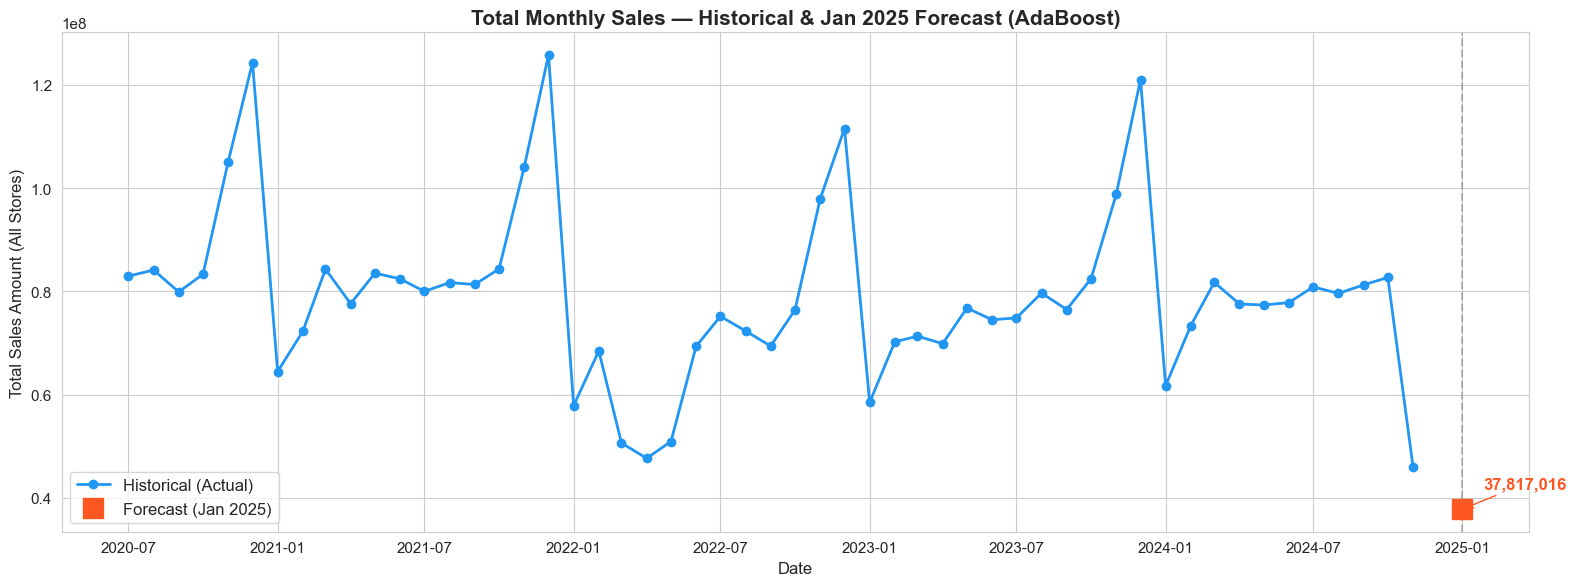

In [27]:
# Historical aggregated sales + the single-month forecast point
hist_agg = df_clean.groupby('date')[TARGET].sum().reset_index()
forecast_total = forecast_df['predicted_sales'].sum()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(hist_agg['date'], hist_agg[TARGET], 'o-', label='Historical (Actual)', color='#2196F3', linewidth=2)
ax.plot(FORECAST_DATE, forecast_total, 's', label='Forecast (Jan 2025)',
        color='#FF5722', markersize=14, zorder=5)

# Annotate the forecast point
ax.annotate(f'{forecast_total:,.0f}', xy=(FORECAST_DATE, forecast_total),
            xytext=(15, 15), textcoords='offset points', fontsize=12, fontweight='bold',
            color='#FF5722', arrowprops=dict(arrowstyle='->', color='#FF5722'))
ax.axvline(FORECAST_DATE, color='gray', linestyle='--', alpha=0.5)

ax.set_title('Total Monthly Sales — Historical & Jan 2025 Forecast (AdaBoost)', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales Amount (All Stores)')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

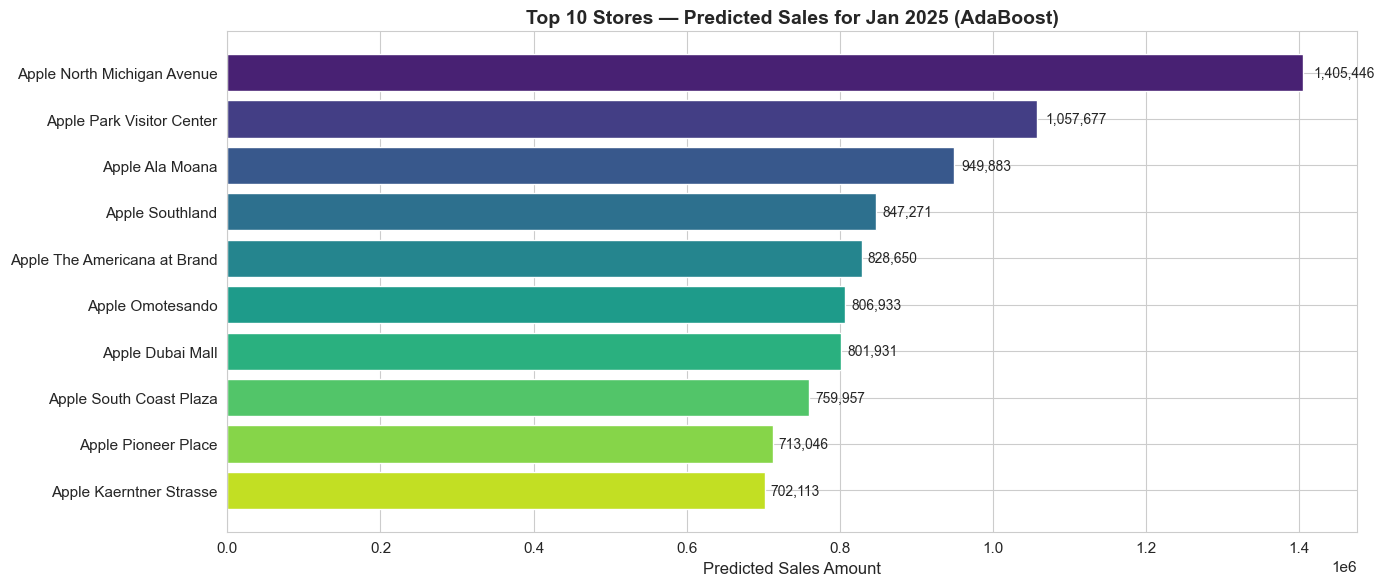

In [28]:
# Top 10 stores by predicted Jan 2025 sales
top10 = forecast_df.nlargest(10, 'predicted_sales')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    top10['store_name'],
    top10['predicted_sales'],
    color=sns.color_palette('viridis', 10)
)
ax.invert_yaxis()
ax.set_xlabel('Predicted Sales Amount')
ax.set_title('Top 10 Stores — Predicted Sales for Jan 2025 (AdaBoost)', fontsize=14, fontweight='bold')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + width * 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 12 · Save Forecast Results

In [29]:
forecast_df.to_csv(PROC / 'adaboost_forecast_jan2025.csv', index=False)
print(f'✅ Forecast saved to {PROC / "adaboost_forecast_jan2025.csv"}')

# Also save the per-store metrics
store_metrics.to_csv(PROC / 'adaboost_store_metrics.csv', index=False)
print(f'✅ Store metrics saved to {PROC / "adaboost_store_metrics.csv"}')

✅ Forecast saved to C:\Users\GM\Desktop\Apple-Retail-Sales-Forcasting\data\processed\adaboost_forecast_jan2025.csv
✅ Store metrics saved to C:\Users\GM\Desktop\Apple-Retail-Sales-Forcasting\data\processed\adaboost_store_metrics.csv


## 13 · Summary

| Step | Details |
|------|---------|
| **Data** | 1M+ transactions → ~3,600 monthly store-level rows |
| **Features** | 52 engineered features (lags, rolling stats, cyclical, economic, categorical) |
| **Model** | AdaBoost with Decision Tree base learners |
| **Tuning** | GridSearchCV with TimeSeriesSplit (5 folds) |
| **Evaluation** | MAE, RMSE, MAPE, R² on temporal hold-out |
| **Forecast** | One-month-ahead prediction (Jan 2025) for all 75 stores |